<a href="https://colab.research.google.com/github/Ailsasahda13/DataMining-Semester4/blob/main/Jobsheet8-Clustering/Dataset%20Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

In [2]:
# Load Dataset iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [5]:
# Pilih fitur (numerik)

features = df.columns
X = df[features]

In [4]:
# Standarisasi data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

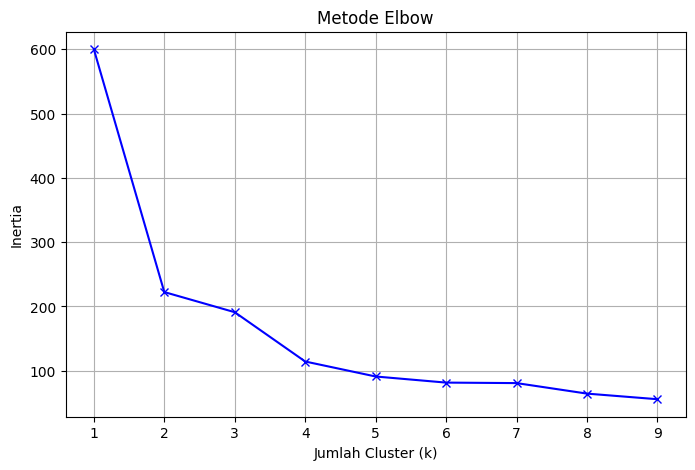

In [6]:
# Tentukan jumlah cluster (elbow)

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow')
plt.grid(True)
plt.show()

In [9]:
# Menjalankan K_Means (misal k=3)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


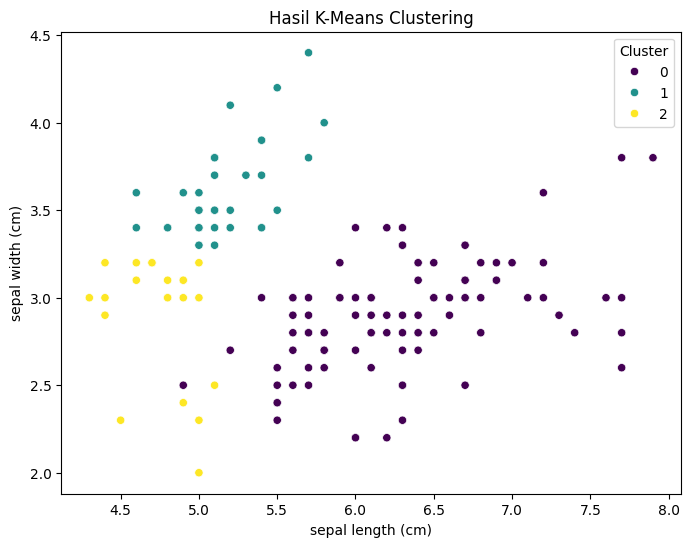

In [10]:
# visualisasi (silhouette score)

plt.figure(figsize=(8,6))
sns.scatterplot(x=df.iloc[:,0],
                y=df.iloc[:,1],
                hue=df['Cluster'],
                palette='viridis')

plt.title('Hasil K-Means Clustering')
plt.show()

In [11]:
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", silhouette_avg)

print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.4798814508199817
Inertia: 191.02473685317958


no 3

In [12]:
from sklearn.cluster import DBSCAN

In [13]:
# Menjalankan DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

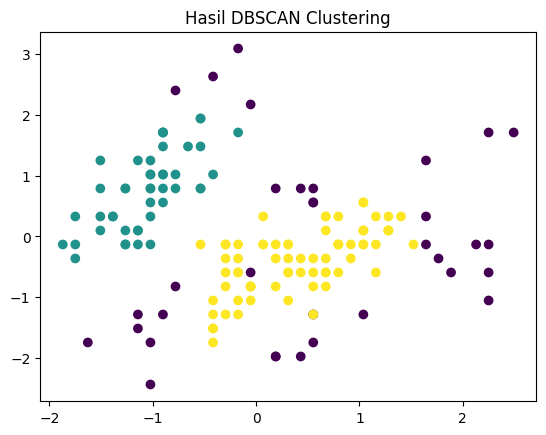

In [14]:
# Visualisasi

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=df['DBSCAN_Cluster'],
            cmap='viridis')

plt.title("Hasil DBSCAN Clustering")
plt.show()

no 4

In [15]:
from sklearn.cluster import AgglomerativeClustering

In [16]:
# clustering

agg_clust = AgglomerativeClustering(n_clusters=3)
df['Hierarchical'] = agg_clust.fit_predict(X_scaled)

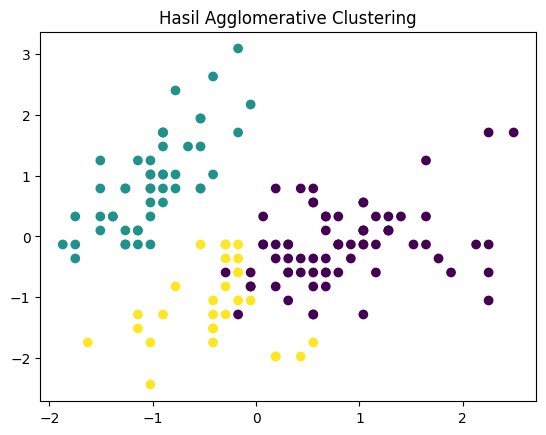

In [17]:
# visualisasi

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=df['Hierarchical'],
            cmap='viridis')

plt.title("Hasil Agglomerative Clustering")
plt.show()